In [ ]:
import os
import pandas as pd

from pathlib import Path

BASE_PATH = Path.cwd().parent.parent

RAW = BASE_PATH / 'Data' / 'raw'
TEMP = BASE_PATH / 'Data' / 'temp'
USE = BASE_PATH / 'Data' / 'use'
FIGURES = BASE_PATH / 'Results' / 'Figures'
TABLES = BASE_PATH / 'Results' / 'Tables'

for path in [RAW, TEMP, USE, FIGURES, TABLES]:
    path.mkdir(parents=True, exist_ok=True)

print(f"✅ BASE_PATH: {BASE_PATH}")


In [2]:
df1 = pd.read_excel(os.path.join(USE, 'dc_exposure_and_coal_plant_life_extension.xls'))
df2 = pd.read_excel(os.path.join(RAW, 'Global-Coal-Plant-Tracker-January-2025.xlsx'), sheet_name='Units')

In [3]:
df2_matched = df2.merge(
    df1,
    left_on='GEM unit/phase ID',
    right_on='GEM_unit_phase_ID',
    how='inner'
)
df2_matched = df2_matched.drop(columns=['GEM unit/phase ID'])

In [4]:
hours_per_year = 365 * 24

df2_matched['Annual_CO2'] = (
    hours_per_year
    * df2_matched['Capacity factor']
    * df2_matched['Capacity (MW)']
    * 1000                           # MW → kW
    * df2_matched['Heat rate (Btu per kWh)']
    * df2_matched['Emission factor (kg of CO2 per TJ)']
    / (9.478e8)                       # Btu → TJdui le
    / 1000                           # kg → t
)

In [5]:
df2_matched['Total_CO2'] = df2_matched['Annual_CO2'] * df2_matched['life_extension']
df2_matched['Total_CO2'].sum()

6048297348.102094

In [6]:
# Calculate the share of additional CO2 emissions caused by lifetime extension in global annual emissions
total_co2_tons = df2_matched['Total_CO2'].sum()
total_co2_gt = total_co2_tons / 1e9  # Convert tons to Gt
global_annual_co2_gt = 13.6939  # Global annual CO2 emissions (Gt)
percentage = (total_co2_gt / global_annual_co2_gt) * 100

print(f"Total additional CO2 emissions: {total_co2_gt:.4f} Gt")
print(f"Percentage of global annual emissions: {percentage:.2f}%")


Total additional CO2 emissions: 6.0483 Gt
Percentage of global annual emissions: 44.17%


In [7]:
df_final = df2_matched[
    ['GEM_unit_phase_ID', 'Start year', 'time1', 'life_expect',
     'life_extension', 'life_extension_ci_bottom',
     'life_extension_ci_top', 'Annual_CO2']
]

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams.update({'font.size': 20})

Total baseline emissions: 27077.83 Mt CO2
Total additional emissions: 6048.30 Mt CO2


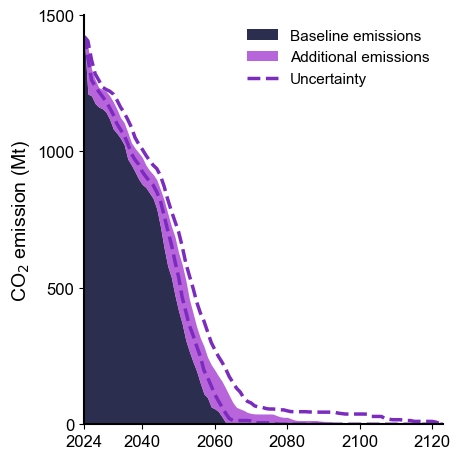

In [10]:
# ================== Basic settings ==================
start_year = 2024

df_final = df2_matched.copy()

# Clean types
df_final["time1"] = df_final["time1"].fillna(0).astype(int)
df_final["life_expect"] = df_final["life_expect"].fillna(0).astype(int)

for col in ["life_extension", "life_extension_ci_bottom", "life_extension_ci_top", "Annual_CO2"]:
    df_final[col] = df_final[col].fillna(0)

# Baseline years under calendar-year accounting
df_final["baseline_years"] = (
    df_final["life_expect"] - df_final["time1"] + 1
).clip(lower=0).astype(int)

# End year based on upper CI
end_year = int(
    start_year
    + (
        df_final["baseline_years"]
        + np.ceil(df_final["life_extension_ci_top"])
    ).max()
)

# ================== Helper function ==================
def expand_stage_emissions(start_year, baseline_years, life_extension, annual_co2, scenario="Central"):
    records = []

    if pd.isna(annual_co2) or annual_co2 <= 0:
        return records

    baseline_years = int(max(0, baseline_years))
    life_extension = max(0, life_extension)

    # Baseline
    if scenario == "Central":
        for i in range(baseline_years):
            records.append({
                "Year": start_year + i,
                "Stage": "Baseline emissions",
                "Scenario": scenario,
                "Annual_CO2": annual_co2
            })

    # Additional
    ext_start_year = start_year + baseline_years
    ext_full = int(np.floor(life_extension))
    ext_rem = life_extension - ext_full

    for i in range(ext_full):
        records.append({
            "Year": ext_start_year + i,
            "Stage": "Additional emissions",
            "Scenario": scenario,
            "Annual_CO2": annual_co2
        })

    if ext_rem > 0:
        records.append({
            "Year": ext_start_year + ext_full,
            "Stage": "Additional emissions",
            "Scenario": scenario,
            "Annual_CO2": annual_co2 * ext_rem
        })

    return records

# ================== Expand to yearly records ==================
records = []

for _, row in df_final.iterrows():
    records += expand_stage_emissions(
        start_year=start_year,
        baseline_years=row["baseline_years"],
        life_extension=row["life_extension"],
        annual_co2=row["Annual_CO2"],
        scenario="Central"
    )

    records += expand_stage_emissions(
        start_year=start_year,
        baseline_years=row["baseline_years"],
        life_extension=row["life_extension_ci_bottom"],
        annual_co2=row["Annual_CO2"],
        scenario="Lower"
    )

    records += expand_stage_emissions(
        start_year=start_year,
        baseline_years=row["baseline_years"],
        life_extension=row["life_extension_ci_top"],
        annual_co2=row["Annual_CO2"],
        scenario="Upper"
    )

df_yearly = pd.DataFrame(records)

# ================== Central emissions ==================
emissions_central = (
    df_yearly[df_yearly["Scenario"] == "Central"]
    .groupby(["Year", "Stage"], as_index=False)["Annual_CO2"]
    .sum()
    .pivot(index="Year", columns="Stage", values="Annual_CO2")
    .fillna(0)
    / 1e6
)

emissions_central = emissions_central.reindex(
    range(start_year, end_year + 1),
    fill_value=0
)

for col in ["Baseline emissions", "Additional emissions"]:
    if col not in emissions_central.columns:
        emissions_central[col] = 0

emissions_central = emissions_central[["Baseline emissions", "Additional emissions"]]

# ================== Uncertainty lines ==================
emissions_unc = (
    df_yearly[df_yearly["Stage"] == "Additional emissions"]
    .groupby(["Year", "Scenario"], as_index=False)["Annual_CO2"]
    .sum()
    .pivot(index="Year", columns="Scenario", values="Annual_CO2")
    .fillna(0)
    / 1e6
)

emissions_unc = emissions_unc.reindex(
    range(start_year, end_year + 1),
    fill_value=0
)

for col in ["Lower", "Upper"]:
    if col not in emissions_unc.columns:
        emissions_unc[col] = 0

# ================== Check total emissions ==================
baseline_total = emissions_central["Baseline emissions"].sum()
additional_total = emissions_central["Additional emissions"].sum()

print(f"Total baseline emissions: {baseline_total:.2f} Mt CO2")
print(f"Total additional emissions: {additional_total:.2f} Mt CO2")

# ================== Plot ==================
fig, ax = plt.subplots(figsize=(5, 5))

baseline_area = ax.fill_between(
    emissions_central.index,
    0,
    emissions_central["Baseline emissions"],
    color="#15173D",
    alpha=0.9,
    linewidth=0,
    label="Baseline emissions"
)

additional_area = ax.fill_between(
    emissions_central.index,
    emissions_central["Baseline emissions"],
    emissions_central["Baseline emissions"] + emissions_central["Additional emissions"],
    color="#B153D7",
    alpha=0.9,
    linewidth=0,
    label="Additional emissions"
)

upper_line, = ax.plot(
    emissions_unc.index,
    emissions_central["Baseline emissions"] + emissions_unc["Upper"],
    color="#7B2CBF",
    linewidth=2.5,
    linestyle="--",
    label="Additional emissions uncertainty"
)

ax.plot(
    emissions_unc.index,
    emissions_central["Baseline emissions"] + emissions_unc["Lower"],
    color="#7B2CBF",
    linewidth=2.5,
    linestyle="--"
)

# Peak year of additional emissions
max_year = emissions_central["Additional emissions"].idxmax()
max_emission = emissions_central["Additional emissions"].max()

ax.set_xlim(start_year, end_year)
ax.set_ylim(0, 1500)
ax.set_yticks([0, 500, 1000, 1500])
ax.set_ylabel("CO$_2$ emission (Mt)", fontsize=14)
ax.tick_params(labelsize=12)

# Force 2024 to appear on x-axis
xticks = ax.get_xticks()
xticks = np.unique(np.append(xticks, start_year))
xticks = xticks[(xticks >= start_year) & (xticks <= end_year)]
ax.set_xticks(xticks)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.5)
ax.spines["bottom"].set_linewidth(1.5)

ax.legend(
    handles=[baseline_area, additional_area, upper_line],
    labels=[
        "Baseline emissions",
        "Additional emissions",
        "Uncertainty"
    ],
    fontsize=11,
    loc="upper right",
    frameon=False
)

plt.tight_layout()
plt.savefig(
    os.path.join(FIGURES, "fig5b.pdf"),
    dpi=300,
    bbox_inches="tight"
)


In [ ]:
# find peak number of Additional emissions
max_year = emissions_central["Additional emissions"].idxmax()
max_emission = emissions_central["Additional emissions"].max()

print(f"Peak year of additional emissions: {max_year}")
print(f"Peak additional emissions: {max_emission:.2f} Mt CO₂")


Peak year of additional emissions: 2052
Peak additional emissions: 220.88 Mt CO₂


In [18]:
# ================== Annual check table (Jupyter display) ==================
check_table = pd.DataFrame({
    "Year": emissions_central.index,
    "Baseline_Mt": emissions_central["Baseline emissions"].values,
    "Additional_Central_Mt": emissions_central["Additional emissions"].values,
    "Additional_Lower_Mt": emissions_unc["Lower"].reindex(emissions_central.index, fill_value=0).values,
    "Additional_Upper_Mt": emissions_unc["Upper"].reindex(emissions_central.index, fill_value=0).values
})

check_table["Lower_Total_Mt"] = (
    check_table["Baseline_Mt"] + check_table["Additional_Lower_Mt"]
)

check_table["Central_Total_Mt"] = (
    check_table["Baseline_Mt"] + check_table["Additional_Central_Mt"]
)

check_table["Upper_Total_Mt"] = (
    check_table["Baseline_Mt"] + check_table["Additional_Upper_Mt"]
)

check_table = check_table.round(2)

display(check_table)


,Year,Baseline_Mt,Additional_Central_Mt,Additional_Lower_Mt,Additional_Upper_Mt,Lower_Total_Mt,Central_Total_Mt,Upper_Total_Mt
0,2024,1421.02,0.00,0.00,0.00,1421.02,1421.02,1421.02
1,2025,1210.53,174.12,133.12,194.56,1343.65,1384.65,1405.09
2,2026,1203.62,97.51,57.57,132.03,1261.19,1301.13,1335.65
3,2027,1175.51,88.28,63.38,108.84,1238.89,1263.79,1284.35
4,2028,1162.66,71.66,56.58,98.42,1219.23,1234.32,1261.07
...,...,...,...,...,...,...,...,...
95,2119,0.00,0.00,0.00,10.58,0.00,0.00,10.58
96,2120,0.00,0.00,0.00,10.42,0.00,0.00,10.42
97,2121,0.00,0.00,0.00,7.75,0.00,0.00,7.75
98,2122,0.00,0.00,0.00,3.04,0.00,0.00,3.04
